In [5]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
%config InlineBackend.figure_format = 'retina'

## Loading necessary Packages

In [6]:
%load_ext autoreload
%autoreload 2
from compatibility_tools import CompatibilityMeasure, ClusteringToolkit
from qutip import *
import os

# Reprducting the results
> Measuring Incompatibility & Clustering Quantum Observables (PRL 130, 170201)

This notebook reproduces the paper's analytic incompatibility computations and example clustering of qubit observables using the helper class in `compatibility_tools.py`.


## Observables with no noise

### Legacy

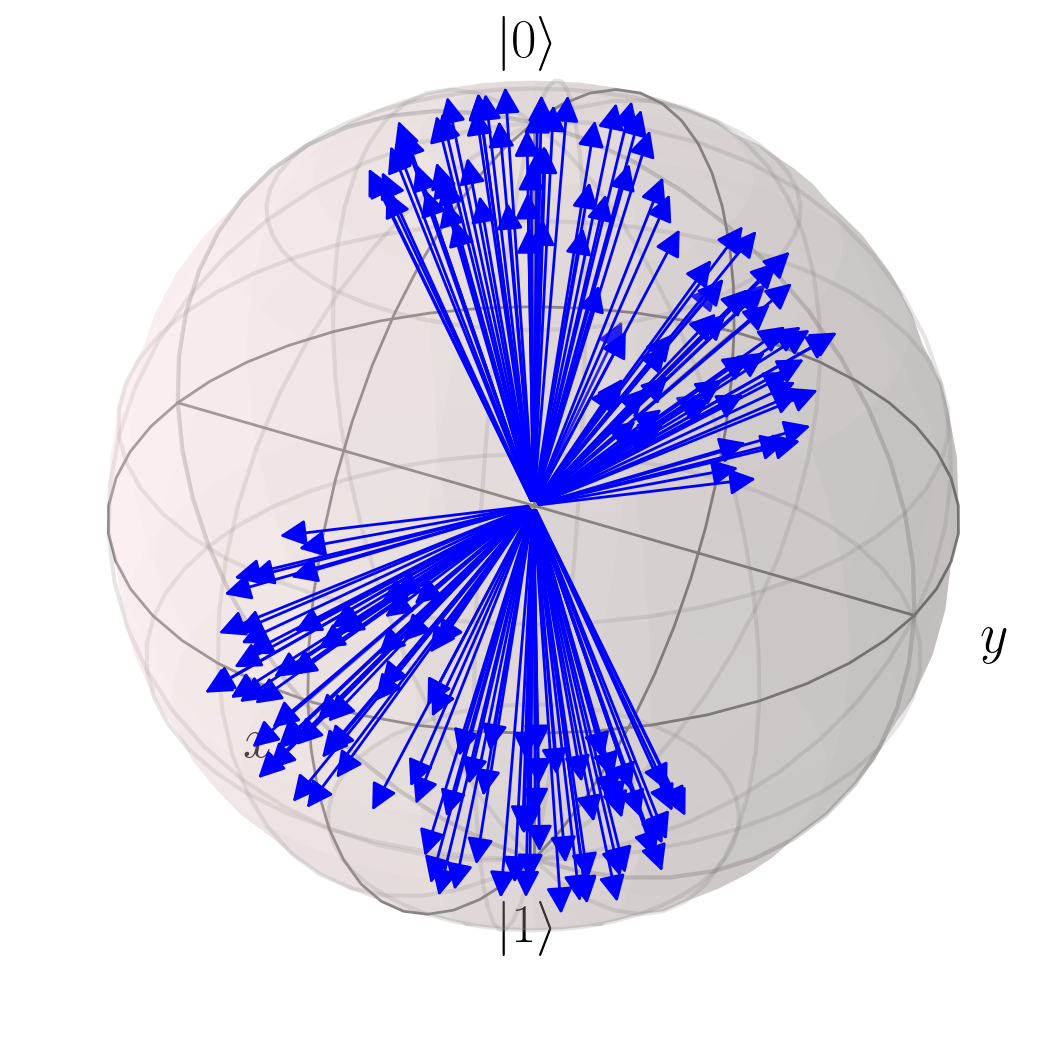

In [13]:
n = 100  # number of observables
vectors_around_x = cm.sample_unit_vectors_cone(n//2, theta_deg=22.5, axis=[1,0,0], rng=np.random.default_rng(42))
vectors_around_z = cm.sample_unit_vectors_cone(n//2, theta_deg=22.5, axis=[0,0,1], rng=np.random.default_rng(43))


# Normalize all vectors to unit length
vectors_around_x = vectors_around_x / np.linalg.norm(vectors_around_x, axis=1, keepdims=True)
vectors_around_z = vectors_around_z / np.linalg.norm(vectors_around_z, axis=1, keepdims=True)
all_vectors = np.vstack([vectors_around_x, vectors_around_z])

observables = [cm.projective_qubit_povm_from_axis(all_vectors[i]) for i in range(n)]

# Plot the axes of all observables on the Bloch sphere
b = Bloch()
b.vector_color = ['blue'] * (2*n)
b.vector_width = 1
for s in observables:
    b.add_states(s) #type: ignore
b.show()


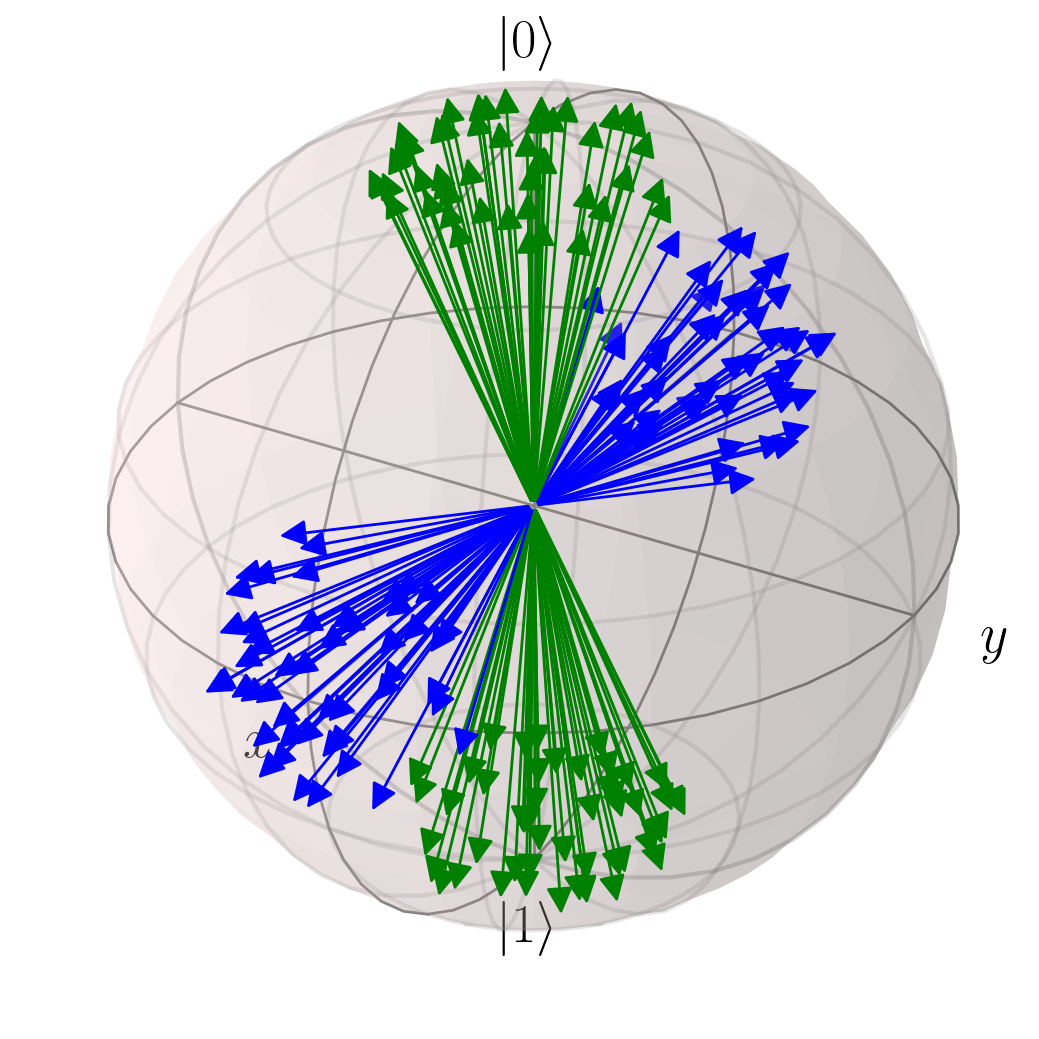

In [14]:
D = cm.incompatibility_distance_matrix(observables)

from compatibility_tools import ClusteringToolkit

labels = ct.cluster_from_distance(D, n_clusters=2, method='kmedoids')

# from sklearn_extra.cluster import KMedoids

# kmedoids = KMedoids(n_clusters=3, metric="precomputed", random_state=0)
# labels = kmedoids.fit_predict(D)

# Plot the axes of all observables on the Bloch sphere
b = Bloch()
b.vector_color = ['b' if labels[i//2]==0 else 'g' for i in range(2*n)]
b.vector_width = 1 
for s in observables:
    b.add_states(s)  # type: ignore
b.show()

os.makedirs("Plots&Data/MLQS", exist_ok=True)
b.fig.savefig("Plots&Data/MLQS/clustered_observables.png", dpi=300)

### New code

In [16]:
%load_ext autoreload
%autoreload 2
cm = CompatibilityMeasure(method = 'numerical')
spread_angle = 11.25
n_points_per_cluster = 50
ct = ClusteringToolkit(cm = cm, n_points = n_points_per_cluster, spread_angle = spread_angle, n_clusters = 2, mubs_array = [1, 1, 0], dimensions = 2)
dataset = ct.prepare_povm_dataset(noisy = False)
clustered_dataset = ct.cluster_povm_dataset(dataset)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[[0.         0.10559937 0.15718461 ... 0.70737205 0.69904015 0.69949951]
 [0.10559937 0.         0.10097258 ... 0.69772131 0.69704015 0.70014213]
 [0.15718461 0.10097258 0.         ... 0.69553181 0.67745367 0.69331317]
 ...
 [0.70737205 0.69772131 0.69553181 ... 0.         0.1500319  0.11804114]
 [0.69904015 0.69704015 0.67745367 ... 0.1500319  0.         0.14421817]
 [0.69949951 0.70014213 0.69331317 ... 0.11804114 0.14421817 0.        ]]


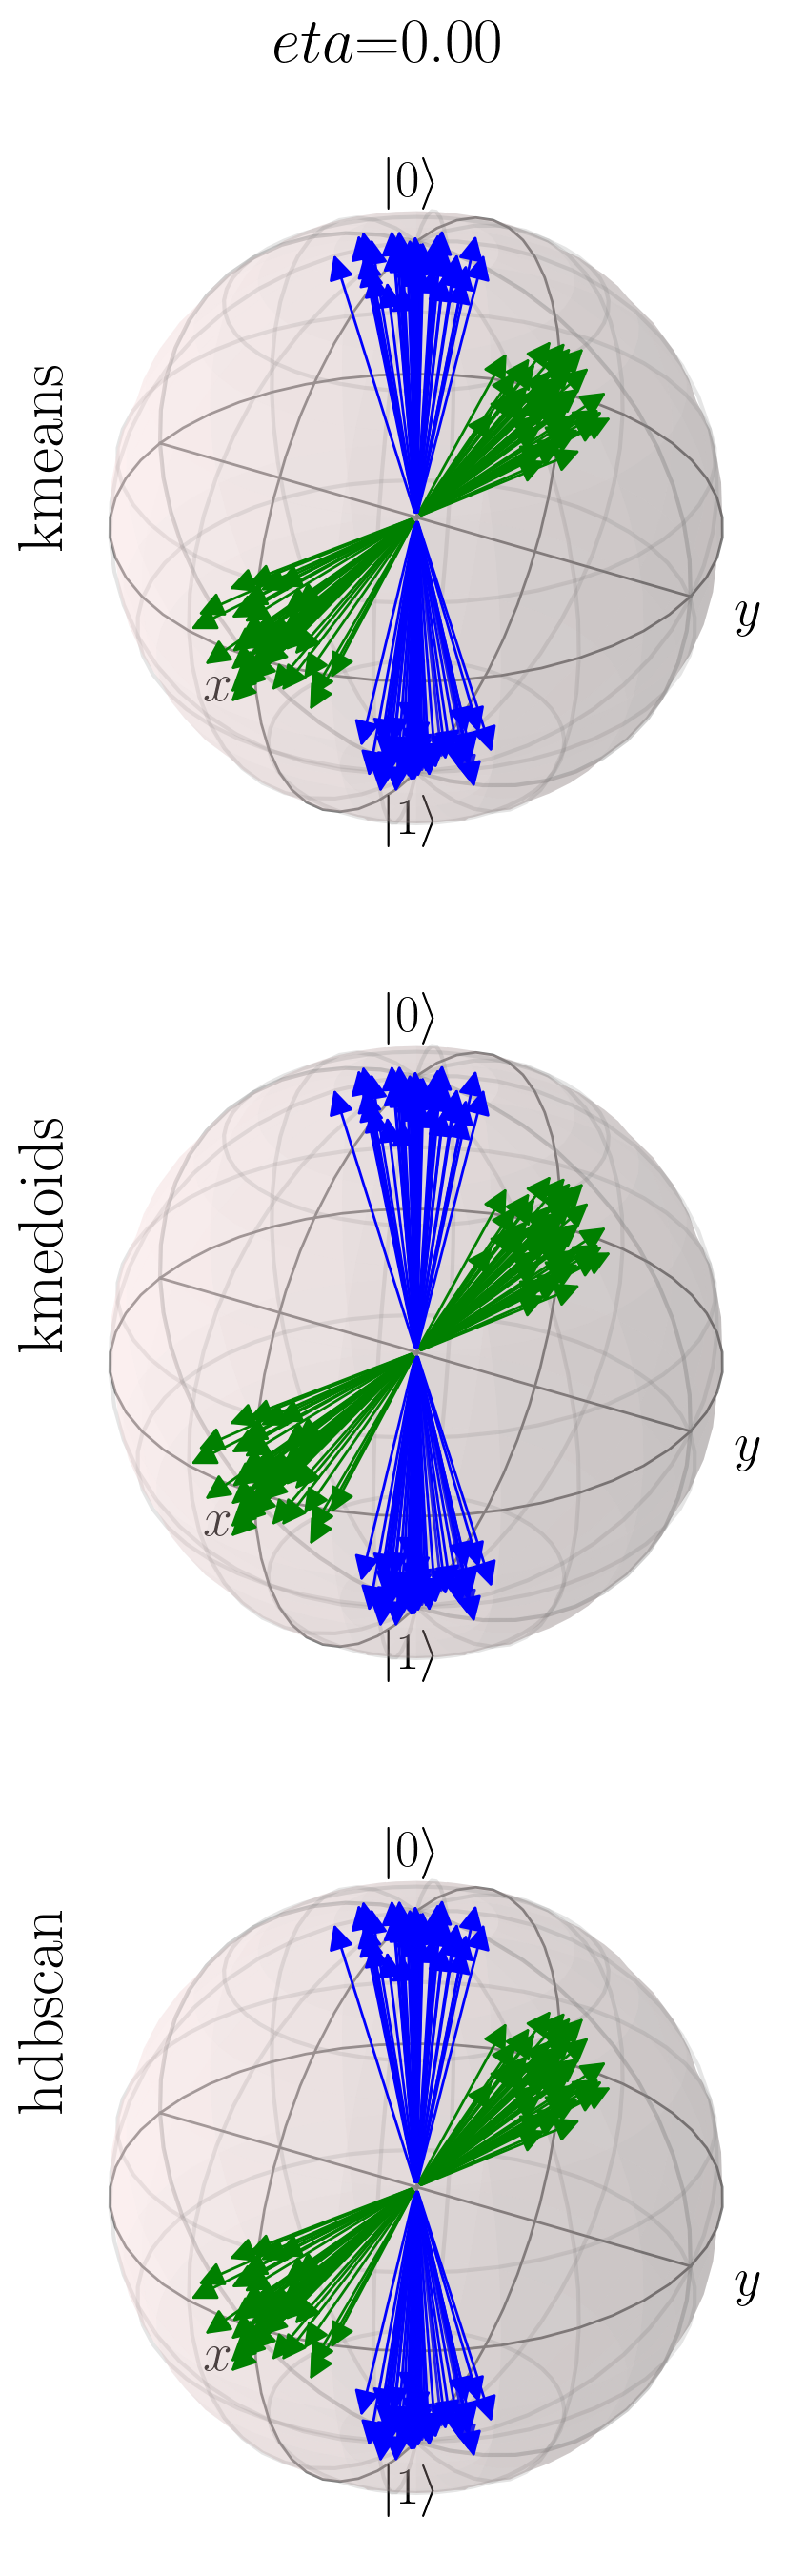

In [17]:
fontsize=24
# set global font sizes
plt.rcParams.update({
    "font.size": fontsize,
    "axes.titlesize": fontsize,
    "axes.labelsize": fontsize,
    "xtick.labelsize": int(fontsize * 0.9),
    "ytick.labelsize": int(fontsize * 0.9),
    "legend.fontsize": int(fontsize * 0.9),
})

# savepath=f"Plots&Data/MLQS/kmeans_kmedoids_comparison_[{spread_angle:.2f}_noiseless].png"
savepath = None
methods = ('kmeans','kmedoids', 'hdbscan')
ct.plot_eta_grid_from_dataset(dataset, methods=methods, savepath=savepath, fontsize=fontsize) 

## Noisy Observables

### Legacy

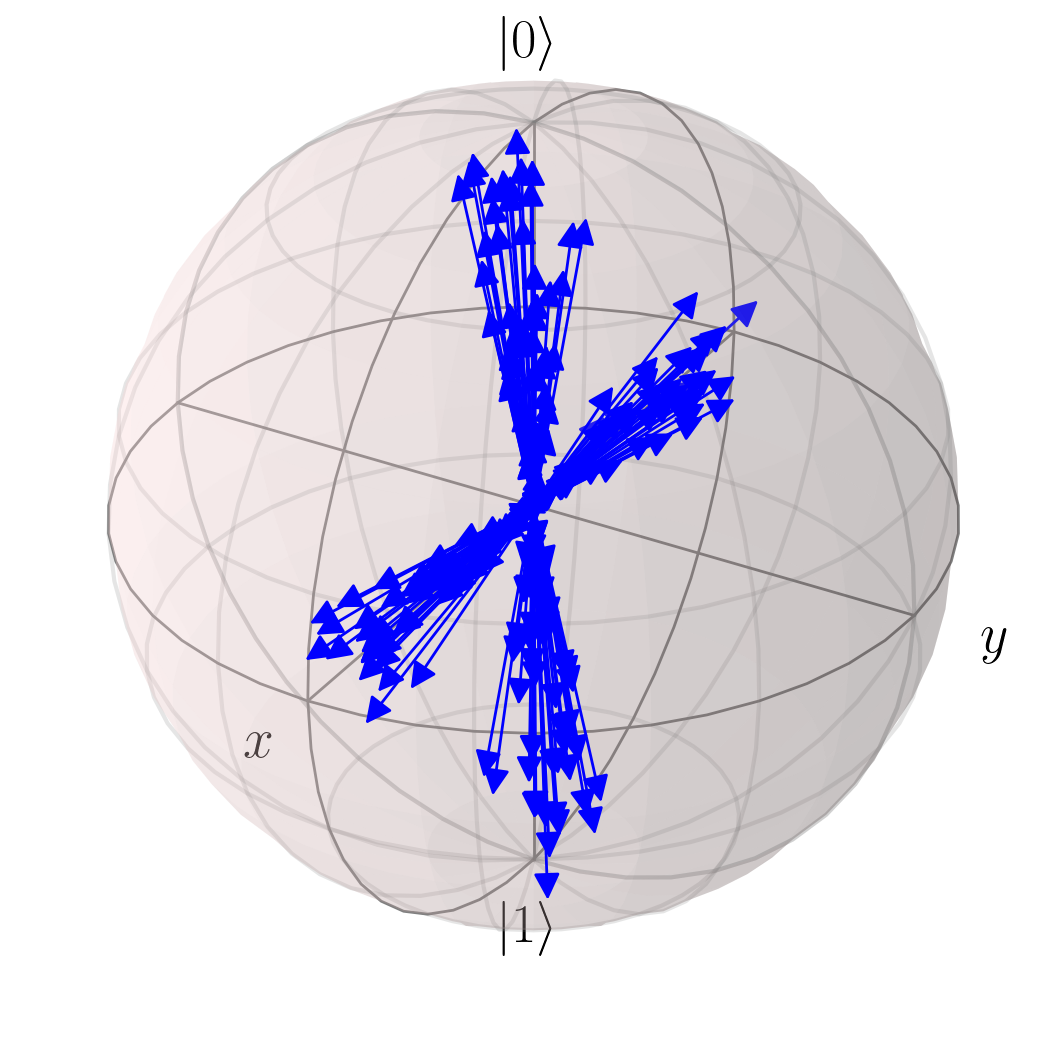

In [54]:
n = 100  # number of observables
spread_angle = 22.5/2  # degrees
vectors_around_x = cm.sample_unit_vectors_cone(n//2, theta_deg=spread_angle, axis=[1,0,0], rng=np.random.default_rng(42))
vectors_around_z = cm.sample_unit_vectors_cone(n//2, theta_deg=spread_angle, axis=[0,0,1], rng=np.random.default_rng(43))

# Normalize all vectors to unit length
vectors_around_x = vectors_around_x / np.linalg.norm(vectors_around_x, axis=1, keepdims=True)
vectors_around_z = vectors_around_z / np.linalg.norm(vectors_around_z, axis=1, keepdims=True)
all_vectors = np.vstack([vectors_around_x, vectors_around_z])

observables = [cm.projective_qubit_povm_from_axis(all_vectors[i]) for i in range(n)]

# Add noise to the observables
max_noise_eta = 0.90
rng = np.random.default_rng(None)
# Sample base_Rl including both endpoints [0, 1]
base_Rl = rng.uniform(low=0, high=1, size=n)
# base_Rl[-1] = 1.0  # explicitly set the last value to the high endpoint
lam = max_noise_eta * base_Rl
noisy_observables, noisy_kraus_ops = [], []
for i, obs in enumerate(observables):
    noisy_obs, noisy_kraus = cm.noisy_povm_with_kraus_qobj(obs, lam=lam[i])
    noisy_observables.append(noisy_obs)
    noisy_kraus_ops.append(noisy_kraus)

# Plot the axes of all observables on the Bloch sphere
b = Bloch()
b.vector_color = ['blue'] * (2*n)
b.vector_width = 1
for s in noisy_observables:
    b.add_states(s) #type: ignore
b.show()


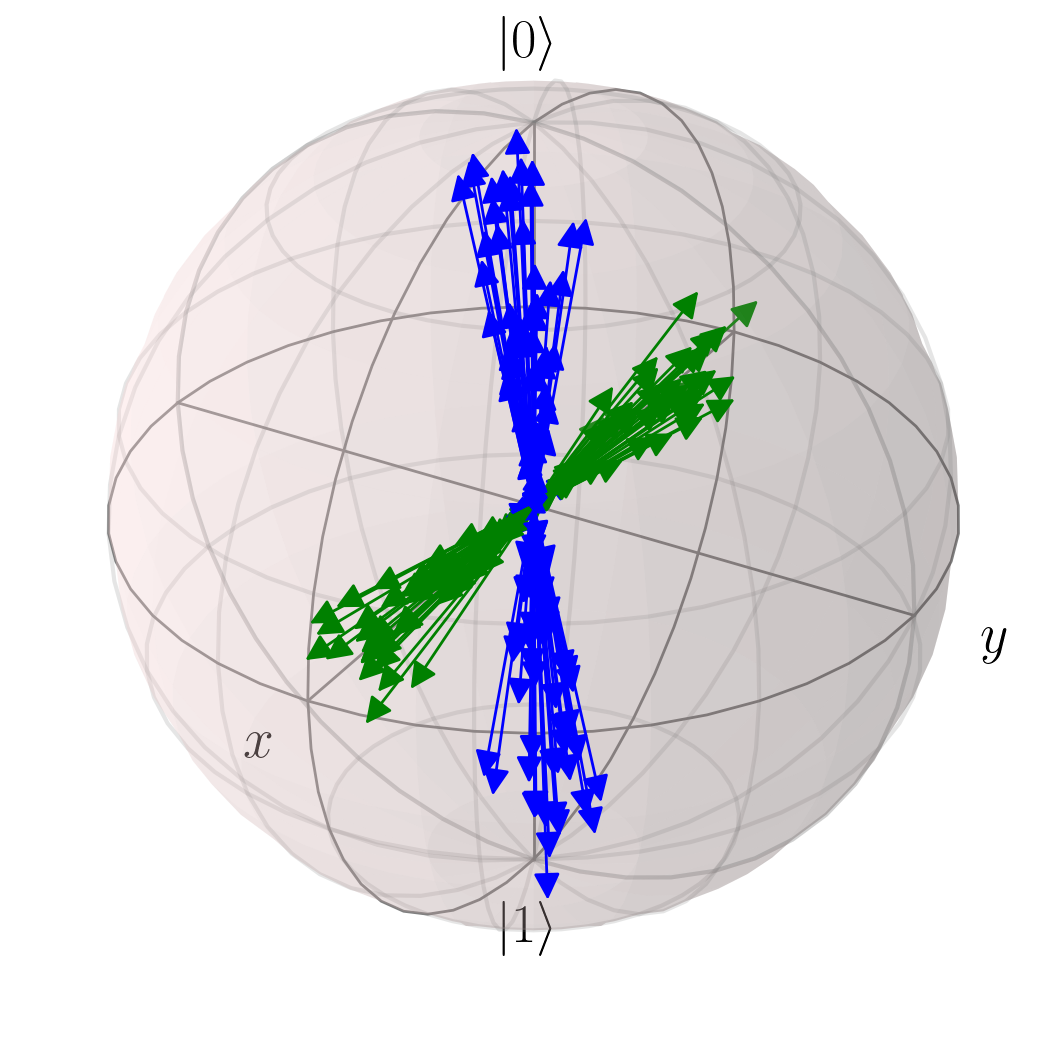

In [56]:
noisy_kraus_ops_flat = [[k for krauses in obs for k in krauses] for obs in noisy_kraus_ops]
D = cm.incompatibility_distance_matrix(noisy_kraus_ops_flat)

from compatibility_tools import ClusteringToolkit

method = 'kmedoids'
method = 'kmeans'

labels = ct.cluster_from_distance(D, n_clusters=2, method=method)

# from sklearn_extra.cluster import KMedoids

# kmedoids = KMedoids(n_clusters=3, metric="precomputed", random_state=0)
# labels = kmedoids.fit_predict(D)

# Plot the axes of all observables on the Bloch sphere
b = Bloch()
b.vector_color = ['b' if labels[i//2]==0 else 'g' for i in range(2*n)]
b.vector_width = 1 
for s in noisy_observables:
    b.add_states(s)  # type: ignore
b.show()

os.makedirs("Plots&Data/MLQS", exist_ok=True)
b.fig.savefig(f"Plots&Data/MLQS/{method}_clustered_noisy_observables_[{spread_angle:.2f}][{max_noise_eta:.2f}].png", dpi=300)

### Comparison (New code)

In [21]:
%reload_ext autoreload
cm = CompatibilityMeasure(method = 'analytical')
spread_angle = 11.25
n_points_per_cluster = 50
ct = ClusteringToolkit(cm = cm, n_points = n_points_per_cluster, spread_angle = spread_angle, n_clusters = 2, mubs_array = [1, 1, 0], dimensions = 2)
etas = [0.25, 0.50, 0.75]
dataset = ct.prepare_povm_dataset(noisy = True, etas = etas)
clustered_dataset = ct.cluster_povm_dataset(dataset, methods=('kmeans','kmedoids','hdbscan'))
# ct.save_noisy_dataset(dataset)  # optional

[[0.         0.70915258 0.70898613 ... 0.75038494 0.79887662 0.77003648]
 [0.70915258 0.         0.70712095 ... 0.74347834 0.79195738 0.76525331]
 [0.70898613 0.70712095 0.         ... 0.73192036 0.76625513 0.74742978]
 ...
 [0.75038494 0.74347834 0.73192036 ... 0.         0.70886919 0.70850239]
 [0.79887662 0.79195738 0.76625513 ... 0.70886919 0.         0.70716223]
 [0.77003648 0.76525331 0.74742978 ... 0.70850239 0.70716223 0.        ]]
[[0.         0.7083617  0.70781692 ... 0.72451698 0.77677036 0.74583713]
 [0.7083617  0.         0.70710698 ... 0.72125074 0.77245718 0.74343816]
 [0.70781692 0.70710698 0.         ... 0.71304696 0.7354706  0.72270299]
 ...
 [0.72451698 0.72125074 0.71304696 ... 0.         0.70766497 0.7075118 ]
 [0.77677036 0.77245718 0.7354706  ... 0.70766497 0.         0.70714382]
 [0.74583713 0.74343816 0.72270299 ... 0.7075118  0.70714382 0.        ]]
[[0.         0.70769138 0.70724376 ... 0.71145881 0.75977023 0.72830303]
 [0.70769138 0.         0.70709902 ... 

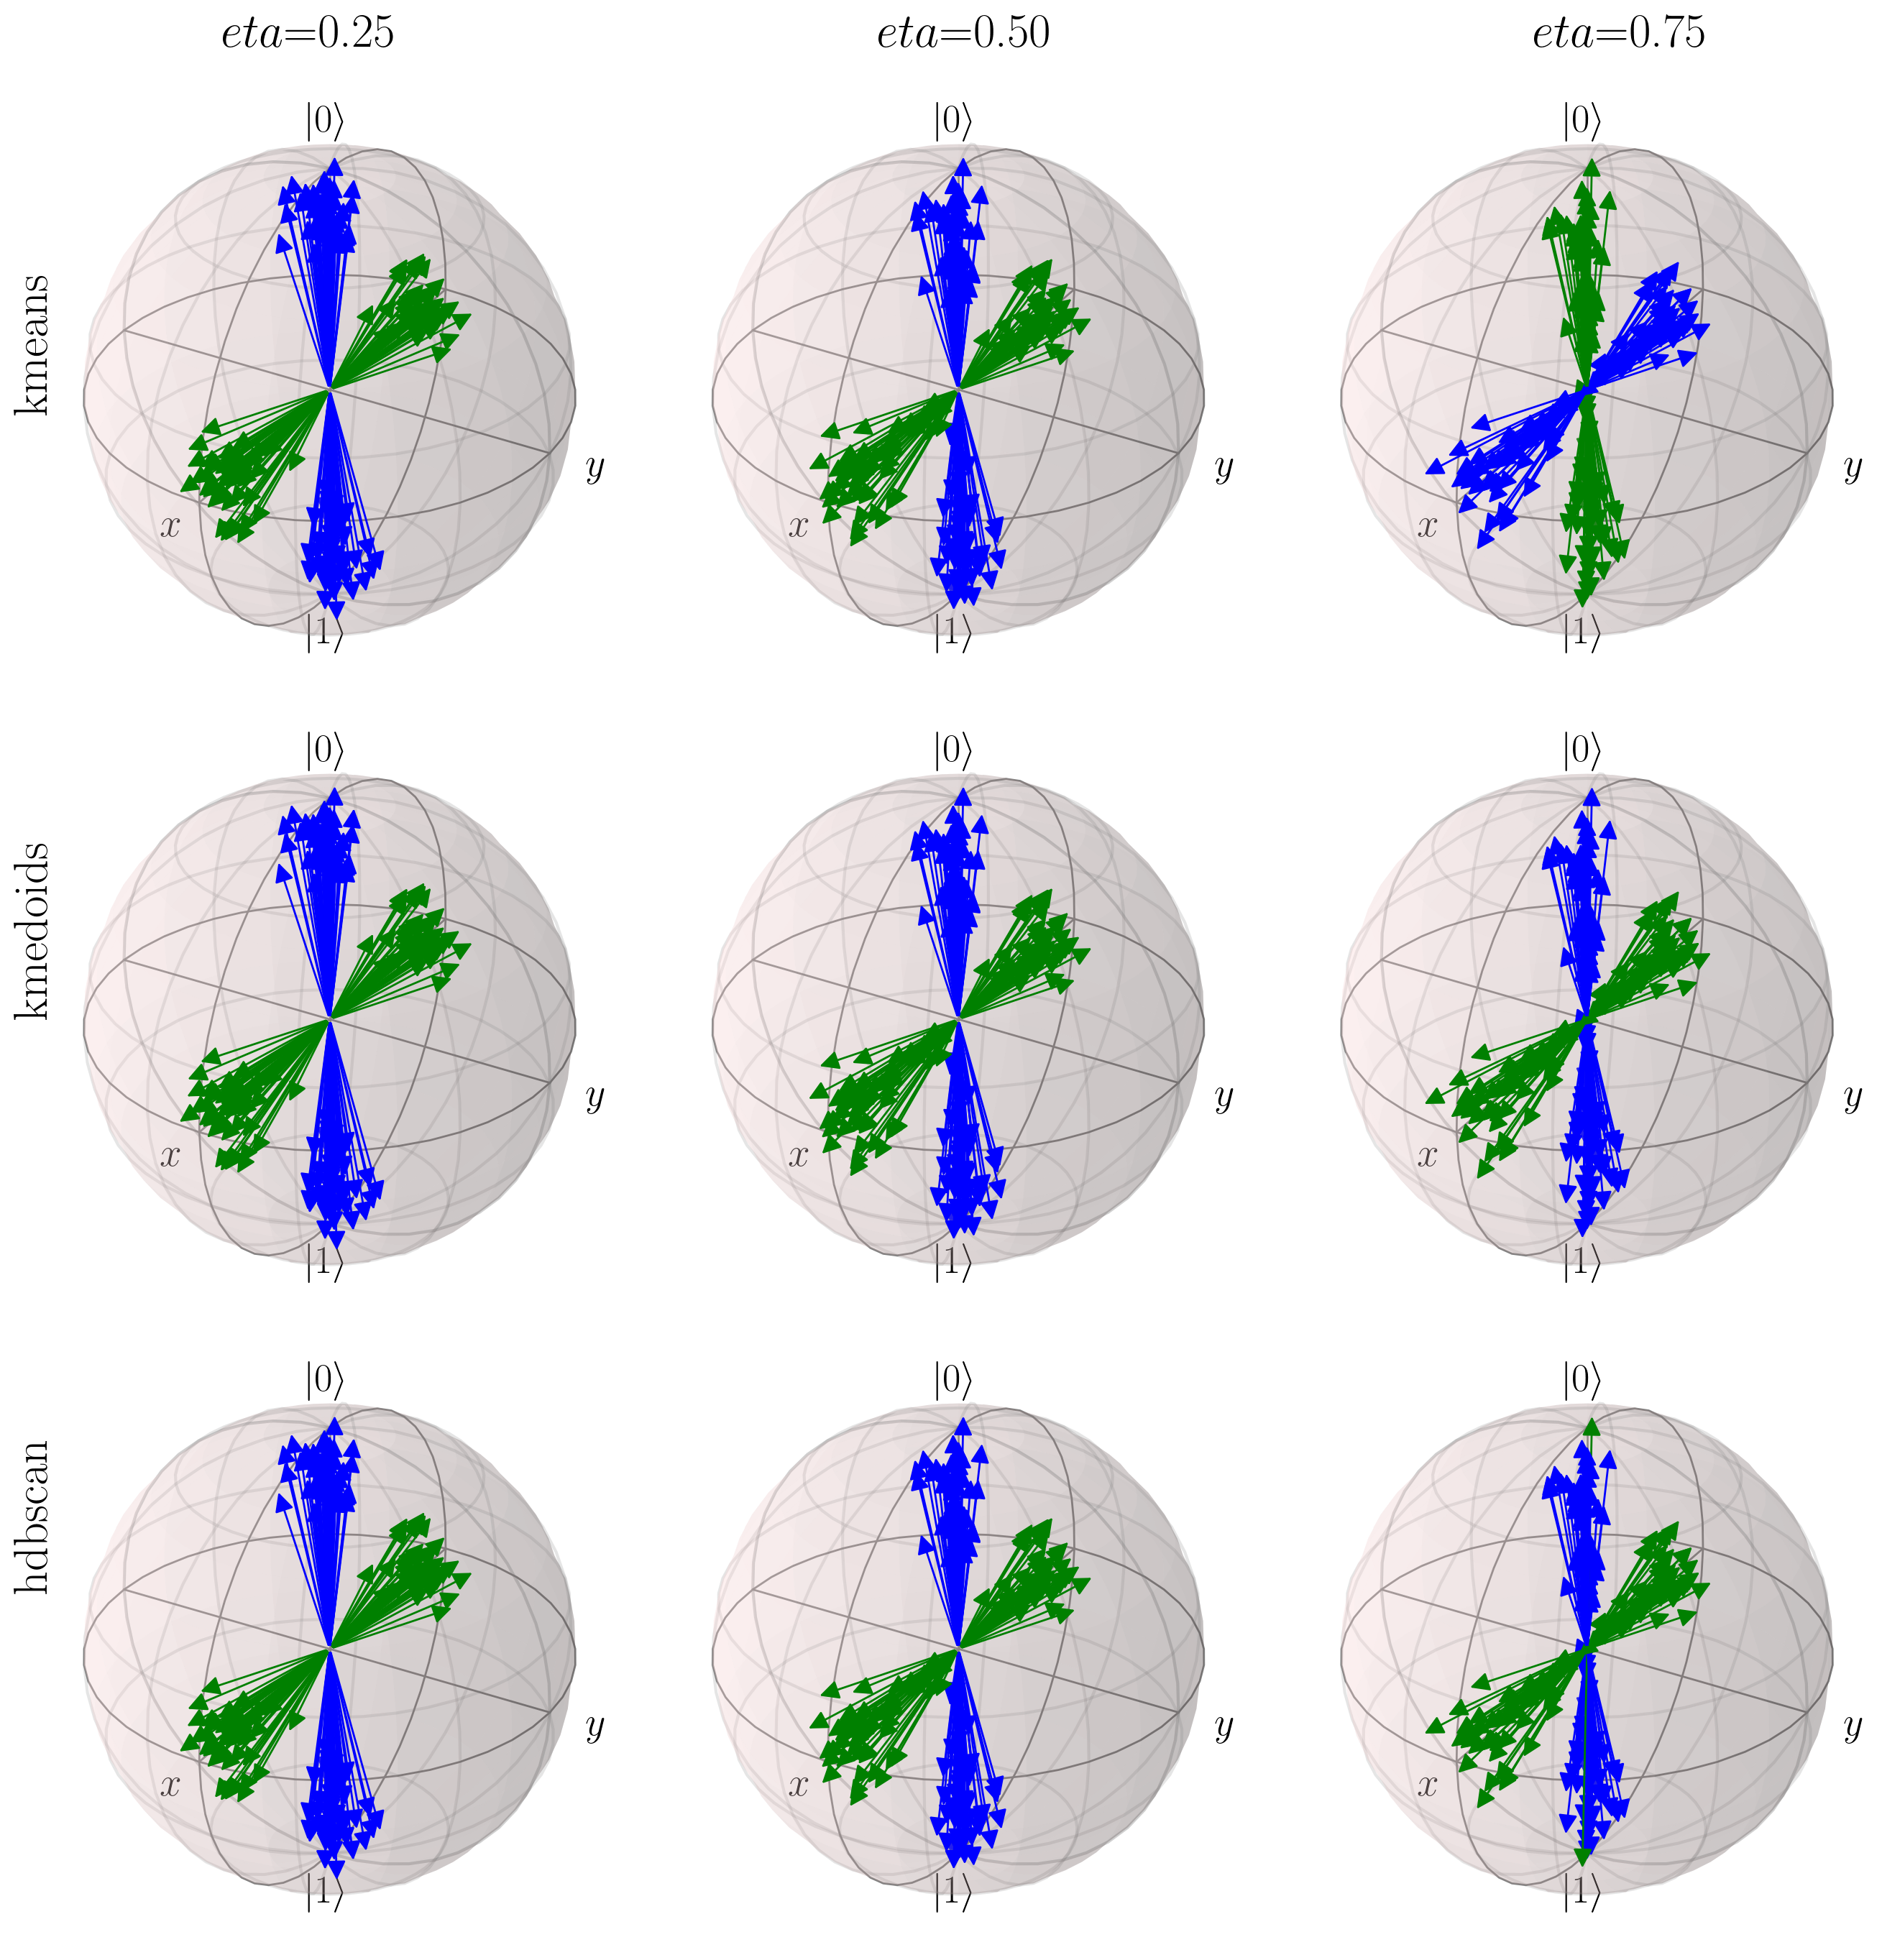

In [22]:
# %reload_ext autoreload
fontsize=24
# set global font sizes
plt.rcParams.update({
    "font.size": fontsize,
    "axes.titlesize": fontsize,
    "axes.labelsize": fontsize,
    "xtick.labelsize": int(fontsize * 0.9),
    "ytick.labelsize": int(fontsize * 0.9),
    "legend.fontsize": int(fontsize * 0.9),
})

savepath=f"Plots&Data/MLQS/kmeans_kmedoids_comparison_[{spread_angle:.2f}].png"
savepath = None
methods = ('kmeans','kmedoids', 'hdbscan')
ct.plot_eta_grid_from_dataset(dataset, methods=methods, savepath=savepath, fontsize=fontsize) 

# Increasing the Number of Clusters

## Without Noise

In [9]:
%load_ext autoreload
%autoreload 2
cm = CompatibilityMeasure(method = 'numerical')
spread_angle = 11.25
n_points_per_cluster = 100
ct = ClusteringToolkit(cm = cm, n_points = n_points_per_cluster, spread_angle = spread_angle, n_clusters = 3, mubs_array = [1, 1, 1], dimensions = 2)
dataset = ct.prepare_povm_dataset(noisy = False)
clustered_dataset = ct.cluster_povm_dataset(dataset)
path_npz = f"Plots&Data/MLQS/clustered_no-noise_dataset_[{spread_angle:.2f}_3clusters].npz"
path_pkl = f"Plots&Data/MLQS/clustered_no-noise_dataset_[{spread_angle:.2f}_3clusters].pkl"
ct.save_dataset(dataset, path_pkl=path_pkl, path_npz=path_npz )

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


('Plots&Data/MLQS/clustered_no-noise_dataset_[11.25_3clusters].npz',
 'Plots&Data/MLQS/clustered_no-noise_dataset_[11.25_3clusters].pkl')

d:\UniVie\Projects\MLQuantumSwitch\Code\compatibility_tools.py:974: SyntaxWarning: invalid escape sequence '\%'
  if annotate:


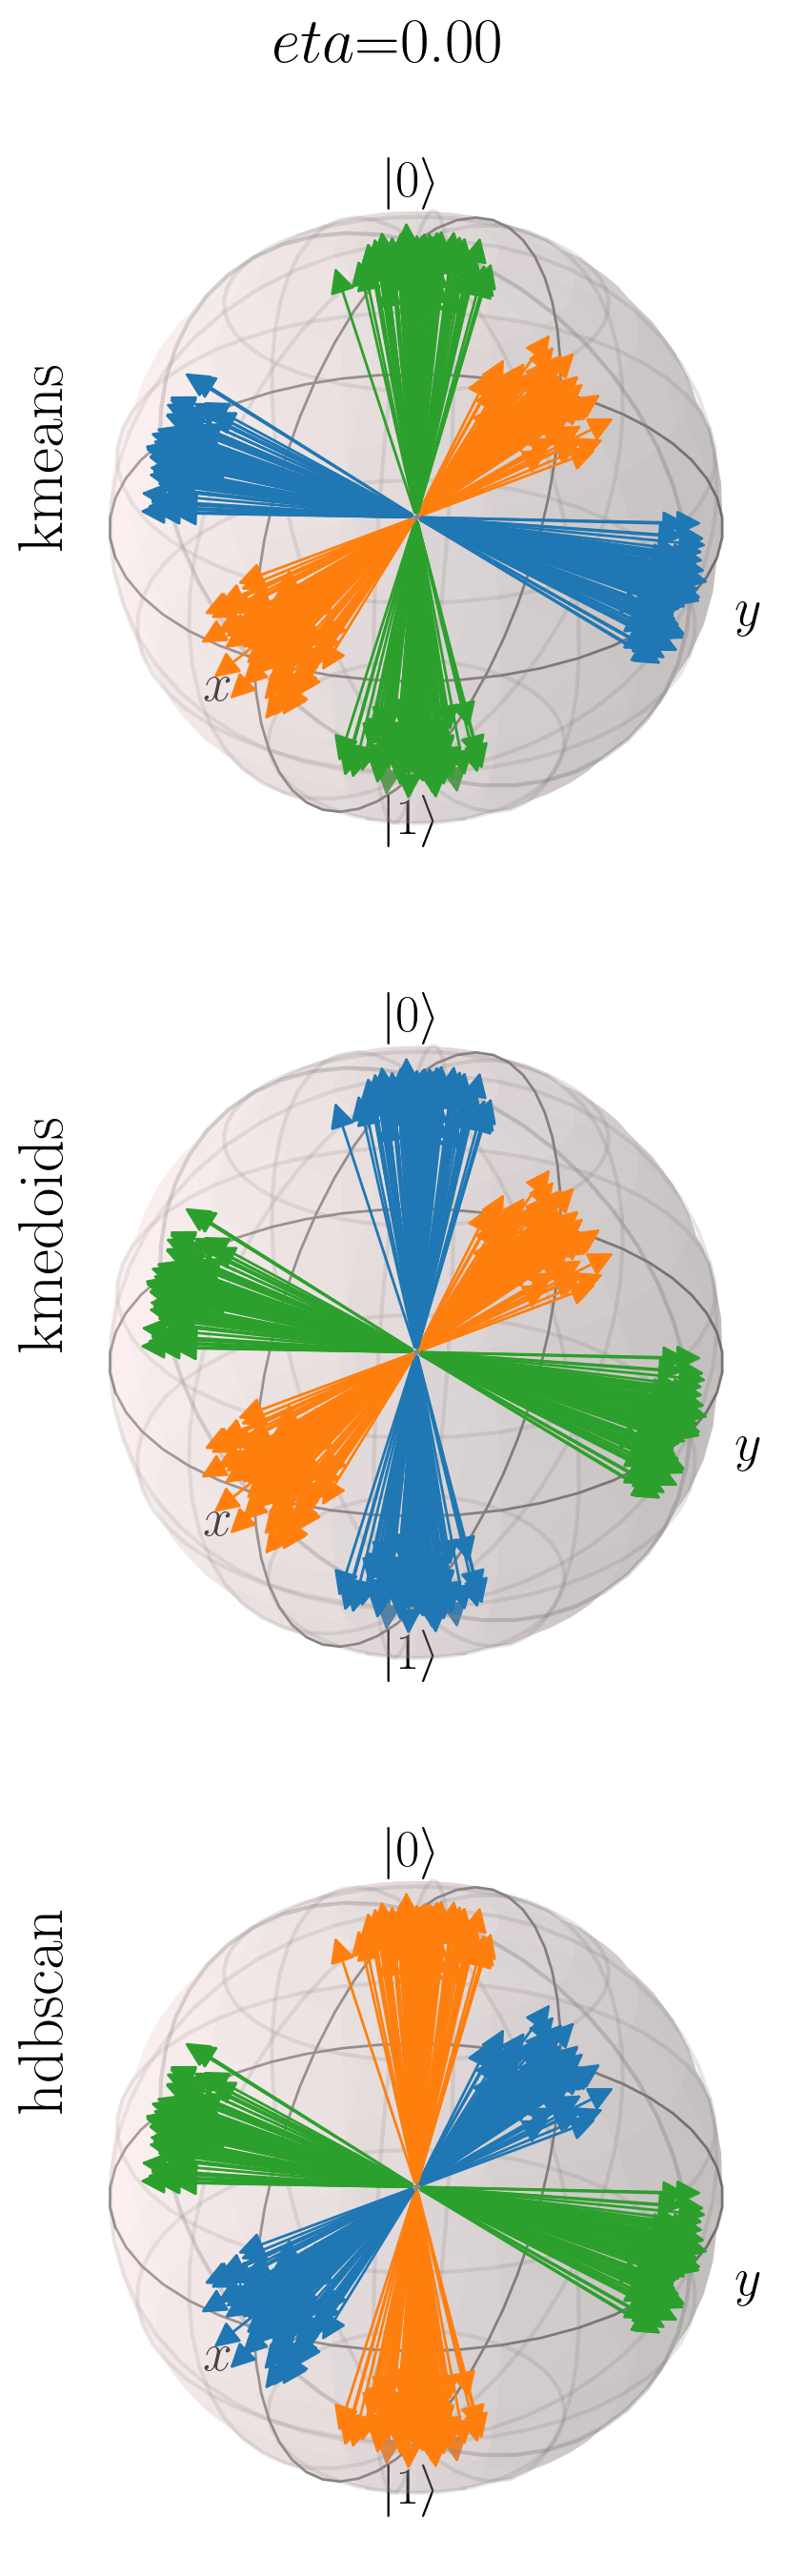

In [ ]:
%reload_ext autoreload
%autoreload 2
fontsize=24
# set global font sizes
plt.rcParams.update({
    "font.size": fontsize,
    "axes.titlesize": fontsize,
    "axes.labelsize": fontsize,
    "xtick.labelsize": int(fontsize * 0.9),
    "ytick.labelsize": int(fontsize * 0.9),
    "legend.fontsize": int(fontsize * 0.9),
})

savepath=f"Plots&Data/MLQS/kmeans_kmedoids_comparison_[{spread_angle:.2f}].png"
savepath = None
methods = ('kmeans','kmedoids', 'hdbscan')
ct.plot_eta_grid_from_dataset(dataset = clustered_dataset, methods=methods, savepath=savepath, fontsize=fontsize) 

## With Noise

In [35]:
%reload_ext autoreload
%autoreload 2
med_method = 'numerical'
cm = CompatibilityMeasure(method = med_method)
spread_angle = 11.25
n_points_per_cluster = 50
ct = ClusteringToolkit(cm = cm, n_points = n_points_per_cluster, spread_angle = spread_angle, n_clusters = 3, mubs_array = [1, 1, 1], dimensions = 2, splits = 1)
etas = [0.25, 0.50, 0.75]
dataset = ct.prepare_povm_dataset(noisy = True, etas = etas)
clustered_dataset = ct.cluster_povm_dataset(dataset)
path_npz = f"Plots&Data/MLQS/clustered_noisy_dataset_[{spread_angle:.2f}_{ct.n_clusters}clusters_{med_method}].npz"
path_pkl = f"Plots&Data/MLQS/clustered_noisy_dataset_[{spread_angle:.2f}_{ct.n_clusters}clusters_{med_method}].pkl"
ct.save_dataset(dataset, path_pkl=path_pkl, path_npz=path_npz)


('Plots&Data/MLQS/clustered_noisy_dataset_[11.25_3clusters_numerical].npz',
 'Plots&Data/MLQS/clustered_noisy_dataset_[11.25_3clusters_numerical].pkl')

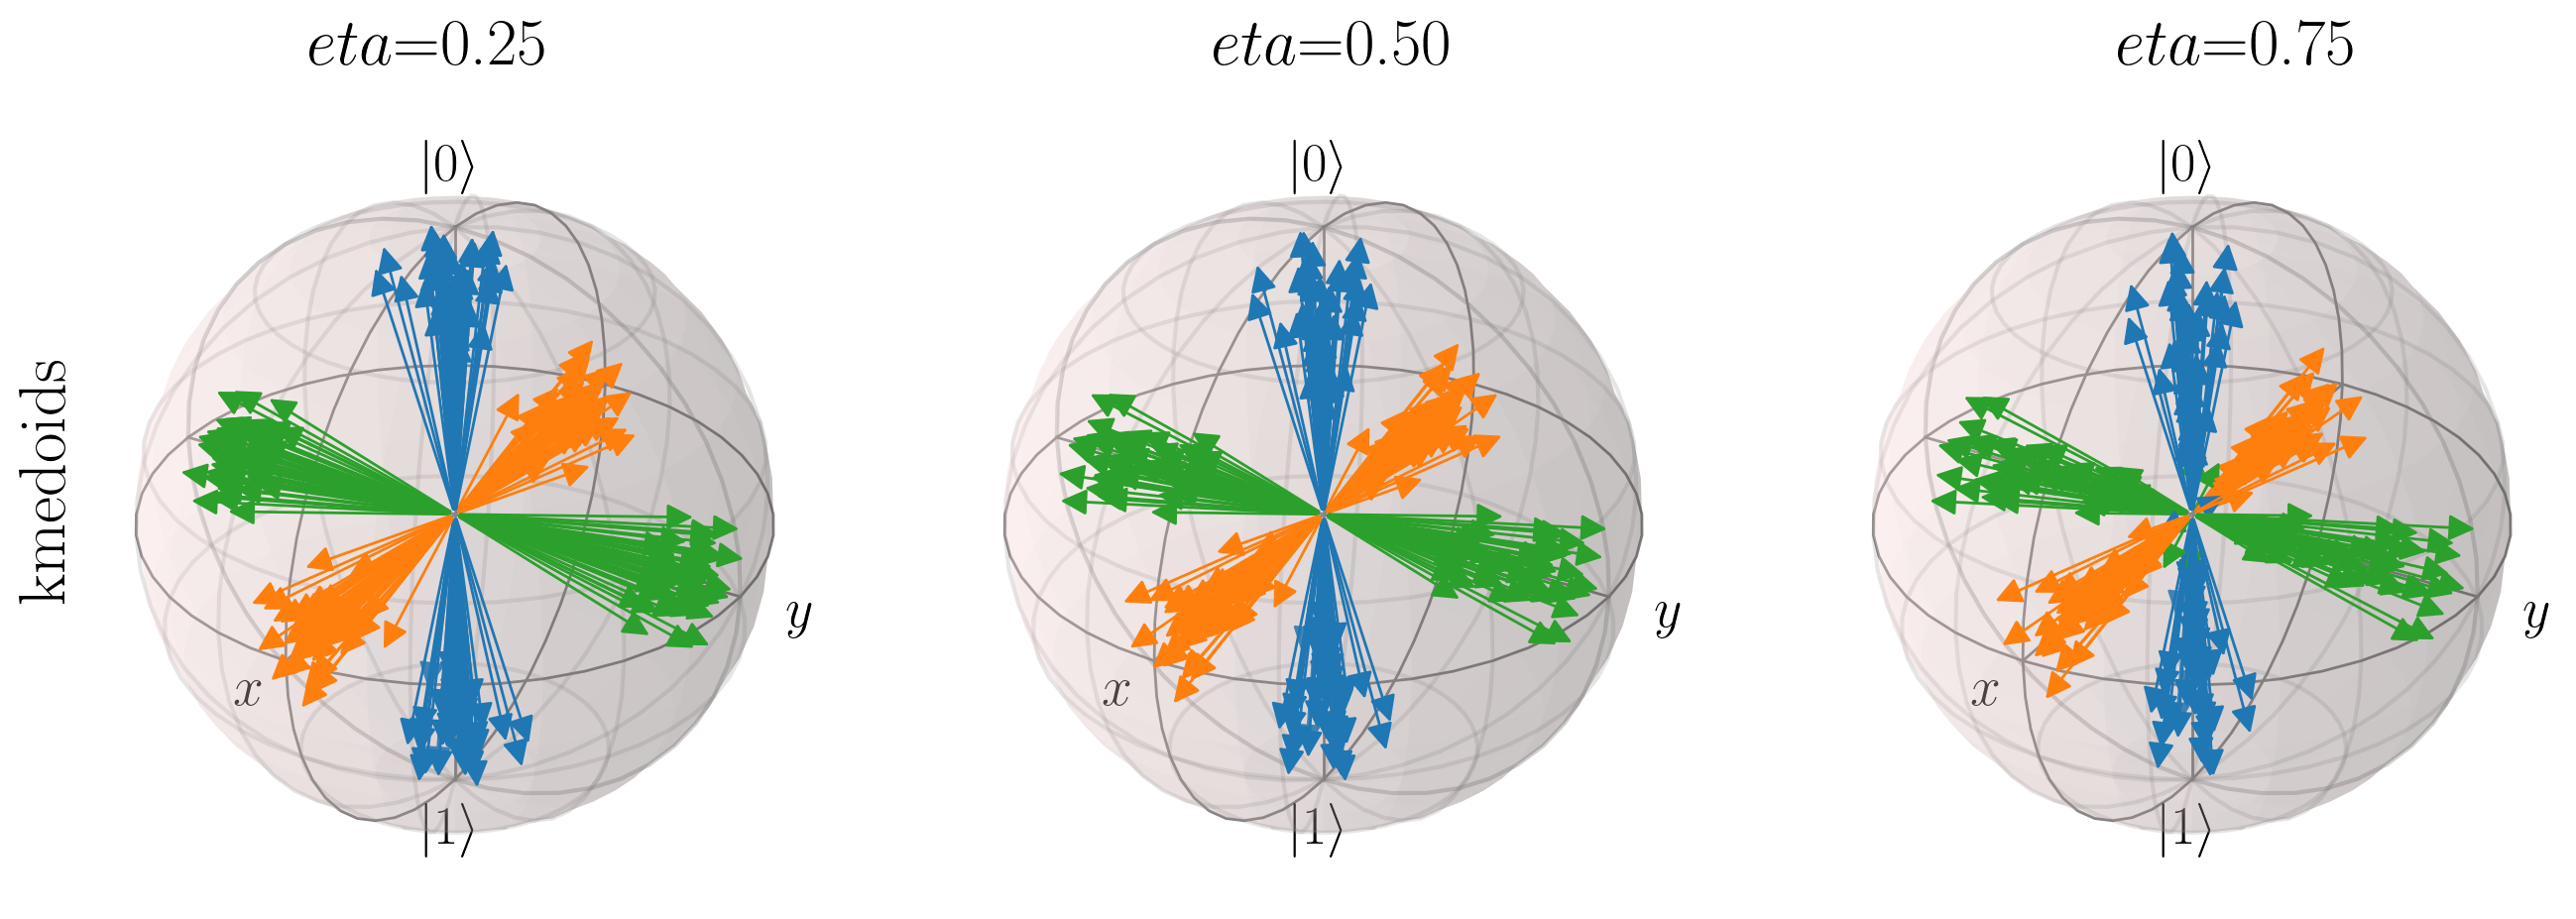

In [36]:
%reload_ext autoreload
%autoreload 2

fontsize=24
# set global font sizes
plt.rcParams.update({
    "font.size": fontsize,
    "axes.titlesize": fontsize,
    "axes.labelsize": fontsize,
    "xtick.labelsize": int(fontsize * 0.9),
    "ytick.labelsize": int(fontsize * 0.9),
    "legend.fontsize": int(fontsize * 0.9),
})

methods = ['kmedoids']
savepath=f"Plots&Data/MLQS/kmedoids_noisy_clustering_[{spread_angle:.2f}_{ct.n_clusters}clusters_{med_method}].png"
# savepath = None
ct.plot_eta_grid_from_dataset(dataset = clustered_dataset, methods=methods, savepath=savepath, fontsize=fontsize) 

# Extending the Method to Higher Dimensions

## Without noise

In [ ]:
%reload_ext autoreload
%autoreload 2
cm = CompatibilityMeasure(method = 'numerical')
spread_angle = 11.25
n_points_per_cluster = 100
ct = ClusteringToolkit(cm = cm, n_points = n_points_per_cluster, spread_angle = spread_angle, n_clusters = 4, mubs_array = [1, 1, 1, 1], dimensions = 3)
dataset = ct.prepare_povm_dataset(noisy = False)
clustered_dataset = ct.cluster_povm_dataset(dataset)
path_npz = f"Plots&Data/MLQS/3dims/clustered_no-noise_dataset_[{spread_angle:.2f}_{ct.n_clusters}clusters_{ct.cm.method}].npz"
path_pkl = f"Plots&Data/MLQS/3dims/clustered_no-noise_dataset_[{spread_angle:.2f}_{ct.n_clusters}clusters_{ct.cm.method}].pkl"
ct.save_dataset(dataset, path_pkl=path_pkl, path_npz=path_npz)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


('Plots&Data/MLQS/3dims/clustered_no-noise_dataset_[11.25_4clusters_numerical].npz',
 'Plots&Data/MLQS/3dims/clustered_no-noise_dataset_[11.25_4clusters_numerical].pkl')

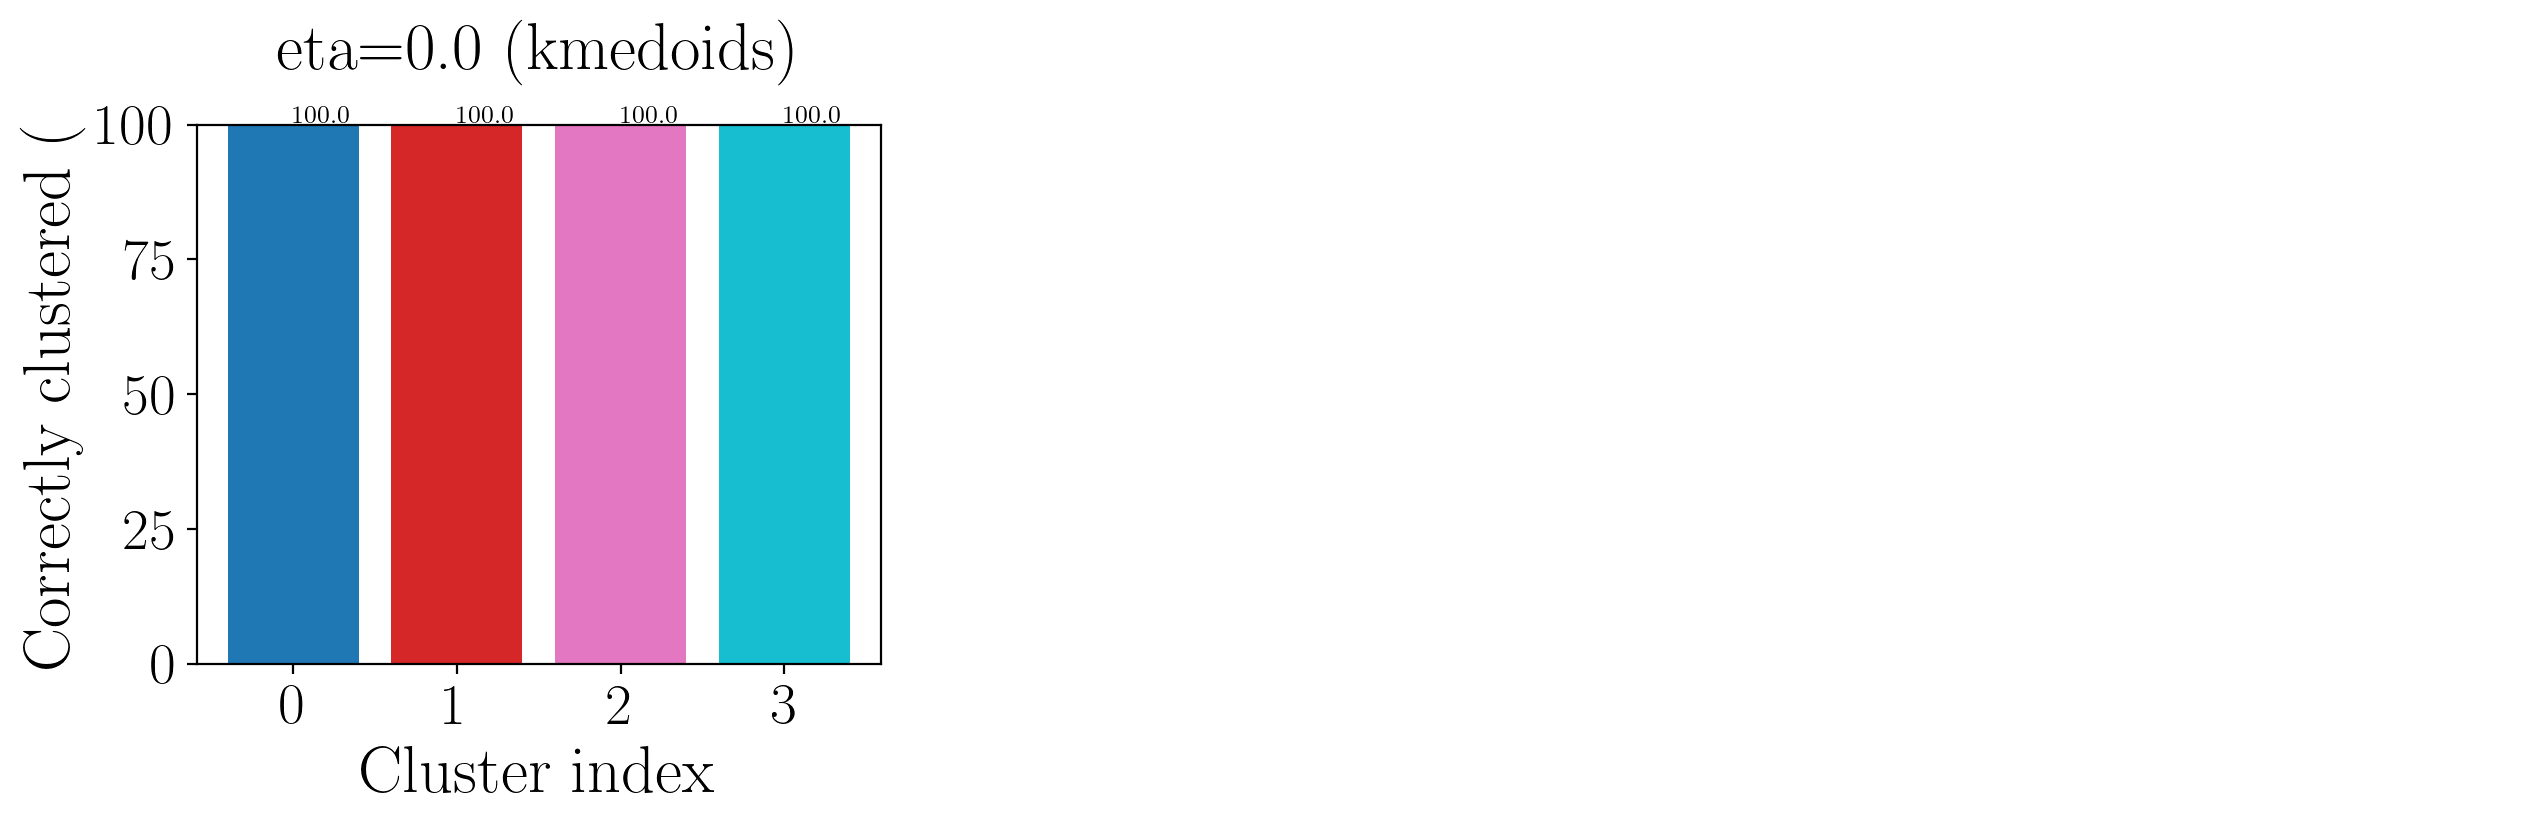

{0.0: array([100., 100., 100., 100.])}

In [42]:
%reload_ext autoreload
%autoreload 2
fontsize=24
# set global font sizes
plt.rcParams.update({
    "font.size": fontsize,
    "axes.titlesize": fontsize,
    "axes.labelsize": fontsize,
    "xtick.labelsize": int(fontsize * 0.9),
    "ytick.labelsize": int(fontsize * 0.9),
    "legend.fontsize": int(fontsize * 0.9),
})

savepath = f"Plots&Data/MLQS/3dims/kmedoids_noiseless_clustering_[{spread_angle:.2f}_{ct.n_clusters}clusters_{ct.cm.method}].png"
# savepath = None
ct.plot_cluster_accuracy_hist(clustered_dataset, savepath=savepath)

## With noise

In [43]:
%load_ext autoreload
%autoreload 2
cm = CompatibilityMeasure(method = 'numerical')
spread_angle = 11.25
n_points_per_cluster = 100
ct = ClusteringToolkit(cm = cm, n_points = n_points_per_cluster, spread_angle = spread_angle, n_clusters = 4, mubs_array = [1, 1, 1, 1], dimensions = 3, splits=1)
etas = [0.25, 0.50, 0.75]
dataset = ct.prepare_povm_dataset(noisy = True, etas = etas)
clustered_dataset = ct.cluster_povm_dataset(dataset)
path_npz = f"Plots&Data/MLQS/3dims/clustered_noisy_dataset_[{spread_angle:.2f}_{ct.n_clusters}clusters_{ct.cm.method}].npz"
path_pkl = f"Plots&Data/MLQS/3dims/clustered_noisy_dataset_[{spread_angle:.2f}_{ct.n_clusters}clusters_{ct.cm.method}].pkl"
ct.save_dataset(clustered_dataset, path_pkl=path_pkl, path_npz=path_npz)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


('Plots&Data/MLQS/3dims/clustered_noisy_dataset_[11.25_4clusters_numerical].npz',
 'Plots&Data/MLQS/3dims/clustered_noisy_dataset_[11.25_4clusters_numerical].pkl')

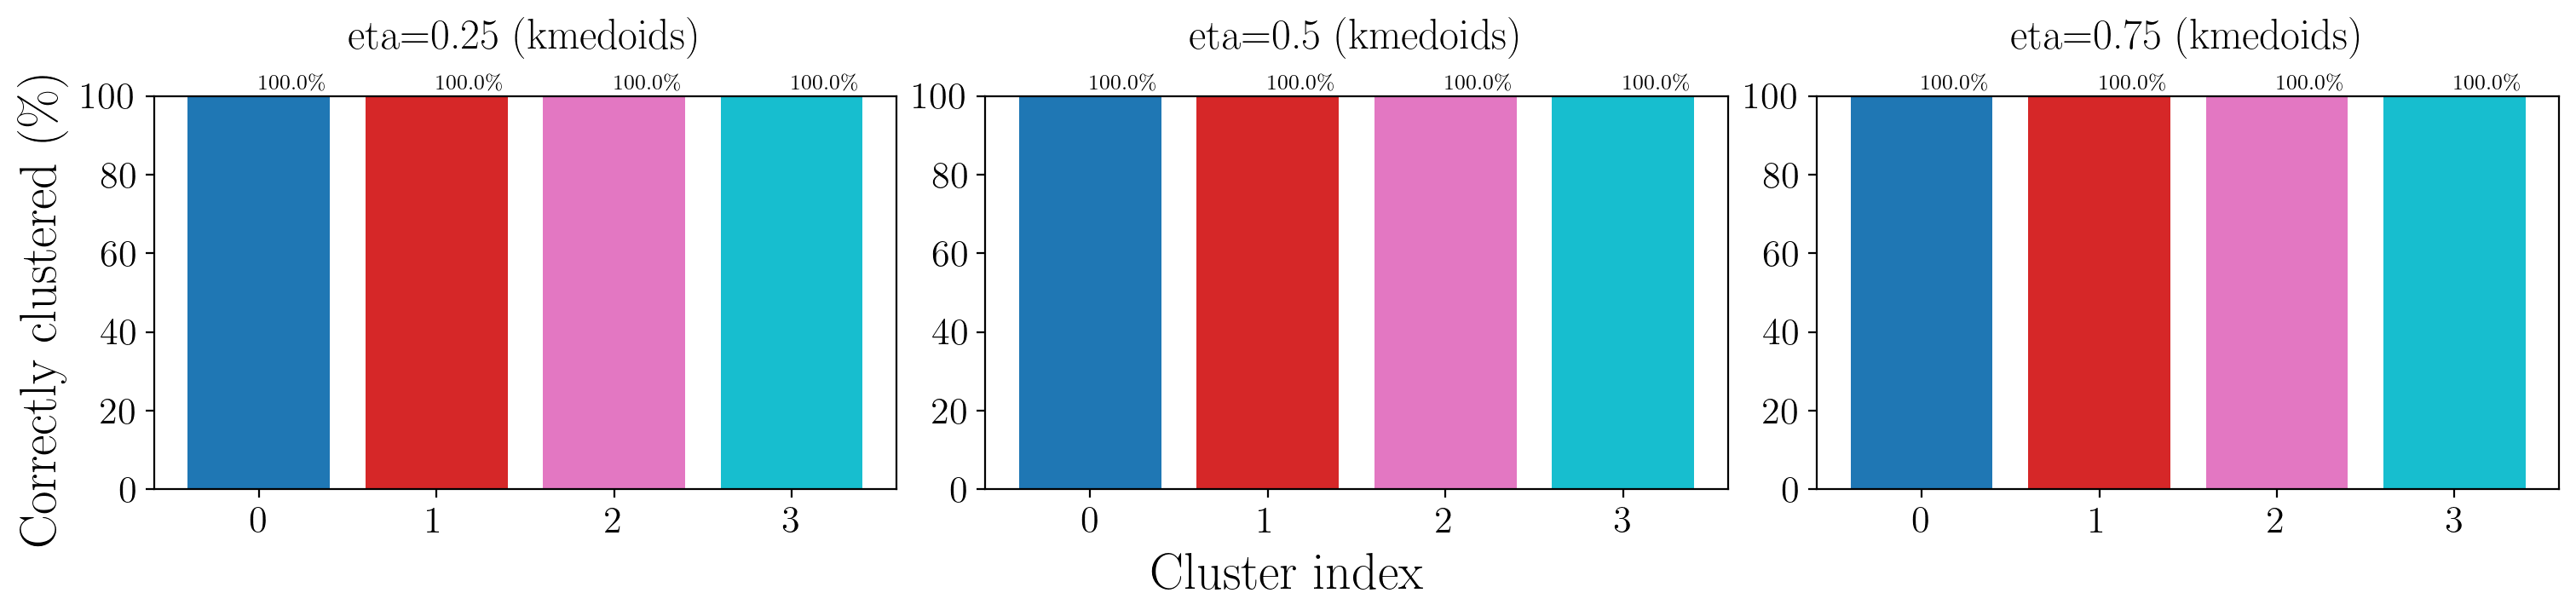

{0.25: array([100., 100., 100., 100.]),
 0.5: array([100., 100., 100., 100.]),
 0.75: array([100., 100., 100., 100.])}

In [49]:
%reload_ext autoreload
%autoreload 2

fontsize=18
# set global font sizes
plt.rcParams.update({
    "font.size": fontsize,
    "axes.titlesize": fontsize,
    "axes.labelsize": fontsize,
    "xtick.labelsize": int(fontsize * 0.9),
    "ytick.labelsize": int(fontsize * 0.9),
    "legend.fontsize": int(fontsize * 0.9),
})

savepath=f"Plots&Data/MLQS/3dims/cluster_accuracy_hist_[{spread_angle:.2f}_{ct.n_clusters}clusters_{ct.cm.method}].png"
# savepath = None
ct.plot_cluster_accuracy_hist(clustered_dataset, savepath=savepath)

# MED Based Kernel for Classification

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

In [9]:
def encoding_2d_point(x1, x2):
    "Encoding a 2D point (x1, x2) into a projective qubit POVM. x1, x2 should be in [0, 1]."
    z_projs = [basis(2,0)*basis(2,0).dag(), basis(2,1)*basis(2,1).dag()] # Z-basis projectors #type: ignore
    H = np.pi * (x1 * sigmax() + x2 * sigmay()) / 2  # Hamiltonian for rotation
    U = (-1j * H).expm()  # Unitary operator for rotation
    encoded_projs = [U * z_projs[0] * U.dag(), U * z_projs[1] * U.dag()]  # Rotated projectors
    for proj in encoded_projs:
        eigenvals, eigenvecs = proj.eigenstates('kets')
        v = eigenvecs[np.argmax(eigenvals)]
        P_clean = v * v.dag() 
        proj = P_clean
    return encoded_projs


In [23]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, random_state=23, n_classes=2, n_clusters_per_class=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=43)
# check raw ranges
print("raw X range:", X.min(axis=0), X.max(axis=0))

# # if your encoder requires strict [0,1], clip the values
# X_train_clipped = np.clip(X_train, 0.0, 1.0)
# X_test_clipped  = np.clip(X_test,  0.0, 1.0)
scaler = MinMaxScaler()
X = scaler.fit_transform(X, y)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("scaled X_train range:", X_train.min(axis=0), X_train.max(axis=0))
print("scaled X_test range:", X_test.min(axis=0), X_test.max(axis=0))

cm = CompatibilityMeasure(method='numerical')
gram_matrix = np.zeros((len(X_train), len(X_train)))
for i in range(len(X_train)):
    for j in range(len(X_train)):
        # Some encoding from X to Operators 
        gram_matrix[i, j] = 1 - (cm.mutual_eigenspace_disturbance(encoding_2d_point(X_train[i,0], X_train[i,1]), encoding_2d_point(X_train[j,0], X_train[j,1])))**2

svc = SVC(kernel='precomputed')
svc.fit(gram_matrix, y_train)
# Predict on the test set
test_gram_matrix = np.zeros((len(X_test), len(X_train)))
for i in range(len(X_test)):
    for j in range(len(X_train)):
        # Some encoding from X to Operators
        test_gram_matrix[i, j] = 1 - (cm.mutual_eigenspace_disturbance(encoding_2d_point(X_test[i,0], X_test[i,1]), encoding_2d_point(X_train[j,0], X_train[j,1])))**2

y_pred = svc.predict(test_gram_matrix)
# Evaluate the accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Test set accuracy: {accuracy * 100:.2f}%")


raw X range: [-2.3404753  -3.69984116] [2.07599128 1.5510826 ]
scaled X_train range: [0. 0.] [1. 1.]
scaled X_test range: [ 0.17404564 -0.02072472] [0.9728152  0.79413564]
Test set accuracy: 93.33%


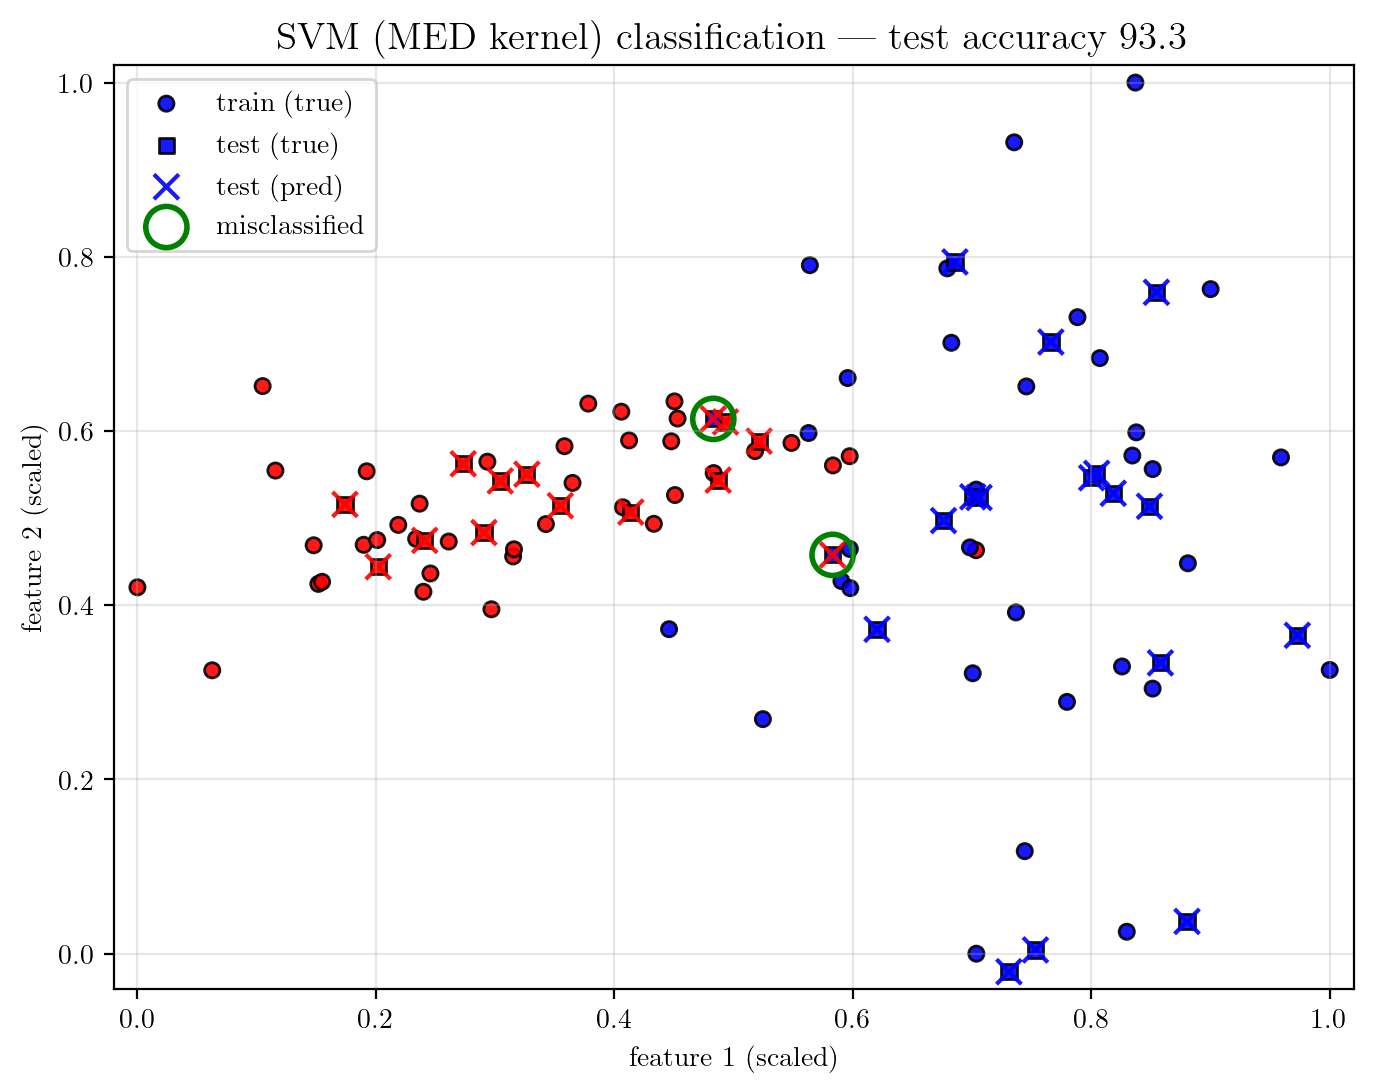

In [24]:

plt.figure(figsize=(8, 6))
cmap = 'bwr'

# Plot training points (true labels)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap, marker='o',
            edgecolors='k', s=30, label='train (true)', alpha=0.9)

# Plot test points (true labels)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cmap, marker='s',
            edgecolors='k', s=30, label='test (true)', alpha=0.9)

# Overlay test predictions
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap=cmap, marker='x',
            s=80, label='test (pred)', alpha=0.9)

# Highlight misclassified test points
mis = (y_pred != y_test)
if mis.any():
    plt.scatter(X_test[mis, 0], X_test[mis, 1], facecolors='none',
                edgecolors='green', s=220, linewidths=2, label='misclassified')

# Layout and labels
plt.title(f"SVM (MED kernel) classification — test accuracy {accuracy*100:.1f}%", fontsize=14)
plt.xlabel("feature 1 (scaled)")
plt.ylabel("feature 2 (scaled)")
plt.legend(loc='best')
plt.grid(alpha=0.3)

# Tight limits with margin
all_xy = np.vstack([X_train, X_test])
xmin, ymin = all_xy.min(axis=0) - 0.02
xmax, ymax = all_xy.max(axis=0) + 0.02
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

plt.show()